# View-Specific (CC, MLO) Training Experiments for all CNNs

* VGG16
* ResNet50
* DenseNet121
* MobileNetV2
* EfficientNet-B0

In [ ]:
# Fixed seed
tf.keras.utils.set_random_seed(123)
tf.config.experimental.enable_op_determinism()

In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, Model, Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.applications import VGG16, ResNet50, DenseNet121, MobileNetV2, EfficientNetB0
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import cv2
import sys
import os

In [ ]:
# Clone the github repository with the source code into this notebook
!git clone https://github.com/Avneetkaur16/CM3070_Final_Project.git
%cd CM3070_Final_Project

Cloning into 'CM3070_Final_Project'...
remote: Enumerating objects: 742, done.
remote: Counting objects: 100% (49/49), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 742 (delta 16), reused 38 (delta 12), pack-reused 693 (from 2)
Receiving objects: 100% (742/742), 23.88 MiB | 29.68 MiB/s, done.
Resolving deltas: 100% (359/359), done.
/content/CM3070_Final_Project


In [ ]:
# Add path to the source code
sys.path.append('/content/CM3070_Final_Project')

In [ ]:
# Import source code functions from repository code
from src.image_preprocessing.image_preprocessors import IMAGE_PREPROCESSORS
from src.utils import *
from src.dataset.dataset import generate_class_weight_dict
from src.workflows.dataset_generation import *
from src.workflows.training_and_evaluation import *
from src.common_model_functions import *
from src.experimental_results_functions import generate_results_metrics_df, store_experiment_results
from src.visualizations import *
from src.constants import BATCH_SIZE, CLASSES, CLASSIFICATION_THRESHOLD, EXPERIMENTAL_EPOCHS

In [ ]:
# Mount the google drive for dataset
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Unzip and extract training and validation datasets (containing images) and store them in the local memory
!unzip -q "/content/drive/MyDrive/CBISDDSM/train_dataset.zip" -d "/content/extracted_train_data"
!unzip -q "/content/drive/MyDrive/CBISDDSM/val_dataset.zip" -d "/content/extracted_val_data"

In [ ]:
# New dataset root path
dataset_root = "/content/drive/MyDrive/CBISDDSM"

In [ ]:
# Extract training and validation metadata CSV files from drive and store them as dataframes
train_df = pd.read_csv(dataset_root + "/train_data.csv")
val_df = pd.read_csv(dataset_root + "/val_data.csv")

In [ ]:
# Update 'image_path' of all dataframes with new image path source
train_df['new_image_path'] = train_df['image_path'].apply(update_image_path_training)
val_df['new_image_path'] = val_df['image_path'].apply(update_image_path_validation)

In [ ]:
# CC-only view
train_df_cc = train_df[train_df['image view'] == 'CC']
val_df_cc = val_df[val_df['image view'] == 'CC']

In [ ]:
# Class distributions for CC
print(train_df_cc['pathology'].value_counts())
print(val_df_cc['pathology'].value_counts())

pathology
0.0    640
1.0    423
Name: count, dtype: int64
pathology
0.0    168
1.0    106
Name: count, dtype: int64


In [ ]:
# MLO-only view
train_df_mlo = train_df[train_df['image view'] == 'MLO']
val_df_mlo = val_df[val_df['image view'] == 'MLO']

In [ ]:
# Class distributions for MLO
print(train_df_mlo['pathology'].value_counts())
print(val_df_mlo['pathology'].value_counts())

pathology
0.0    731
1.0    481
Name: count, dtype: int64
pathology
0.0    189
1.0    124
Name: count, dtype: int64


In [ ]:
# Validation set true labels for evaluation
val_true_labels_cc = val_df_cc['pathology'].to_numpy()
val_true_labels_mlo = val_df_mlo['pathology'].to_numpy()

In [ ]:
# CSV Files to store all experimental results
results_file_path = "/content/drive/MyDrive/CM3070_Final_Project_Experiment_Results/views_experiment_results.csv"

In [ ]:
# Buffer size for shuffling in training dataset
BUFFER_SIZE_CC = len(train_df_cc)
BUFFER_SIZE_MLO = len(train_df_mlo)
# No. of training samples in CC and MLO dataframes for class weight
TOTAL_TRAINING_SAMPLES_CC = len(train_df_cc)
TOTAL_TRAINING_SAMPLES_MLO = len(train_df_mlo)

In [ ]:
# Early stopping
early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

In [ ]:
# Class-Imbalance Handling
class_weights_dict_cc = generate_class_weight_dict(train_df_cc, CLASSES, TOTAL_TRAINING_SAMPLES_CC)
class_weights_dict_mlo = generate_class_weight_dict(train_df_mlo, CLASSES, TOTAL_TRAINING_SAMPLES_MLO)

In [ ]:
# Image preprocessor
baseline_preprocessor = IMAGE_PREPROCESSORS['baseline']

## CC view only Experiment

#### tf.data Datasets for CC-only View

In [ ]:
# Generate training and validation datasets for CC only
train_dataset_cc = dataset_preparation(train_df_cc, baseline_preprocessor, BUFFER_SIZE_CC, BATCH_SIZE, training=True)
val_dataset_cc = dataset_preparation(val_df_cc, baseline_preprocessor, BUFFER_SIZE_CC, BATCH_SIZE, training=False)

### VGG16

In [ ]:
# Select the VGG16 model
vgg16_model_cc = select_model('vgg16')
# Compile and train the VGG16 model with training data
vgg16_cc, _, _ = train_selected_model(vgg16_model_cc, train_dataset_cc, val_dataset_cc, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict_cc)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 26s 492ms/step - auc: 0.3970 - loss: 1.0428 - precision: 0.4032 - recall: 0.4232 - val_auc: 0.4276 - val_loss: 0.7113 - val_precision: 0.4444 - val_recall: 0.2642
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 472ms/step - auc: 0.4511 - loss: 0.8702 - precision: 0.4677 - recall: 0.4444 - val_auc: 0.4827 - val_loss: 0.6526 - val_precision: 0.5397 - val_recall: 0.3208
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 478ms/step - auc: 0.4405 - loss: 0.8512 - precision: 0.4485 - recall: 0.4019 - val_auc: 0.5091 - val_loss: 0.6543 - val_precision: 0.5417 - val_recall: 0.4906
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 474ms/step - auc: 0.4722 - loss: 0.7863 - precision: 0.4932 - recall: 0.4279 - val_auc: 0.5339 - val_loss: 0.6226 - val_precision: 0.5735 - val_recall: 0.3679
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 479ms/step - auc: 0.4890 - loss: 0.7730 - precision: 0.5239 - recall: 0.4657 - val_auc: 0.5602 - val_lo

In [ ]:
# Predictions and evaluations using the trained VGG16 model
_, _, metrics_dict_vgg16_cc, _ = generate_predictions_and_evaluations(vgg16_cc, val_dataset_cc, val_true_labels_cc, CLASSIFICATION_THRESHOLD)

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 278ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 218ms/step - auc: 0.6136 - loss: 0.5580 - precision: 0.7119 - recall: 0.3962


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_cc_results_df = generate_results_metrics_df(
    model_name='VGG16',
    experimental_value='CC-Only-View',
    eval_metrics=metrics_dict_vgg16_cc,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, vgg16_cc_results_df)

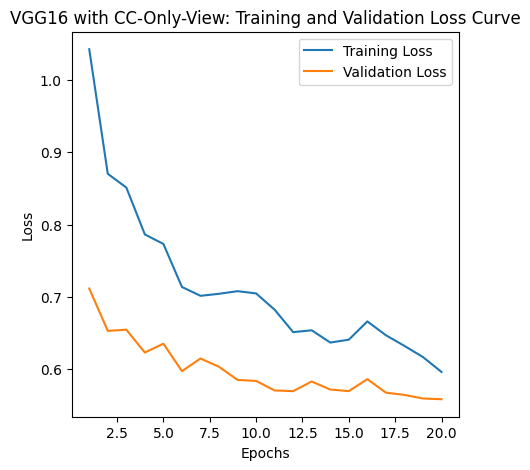

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_cc.history, 'VGG16', 'CC-Only-View')

### ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model_cc = select_model('resnet50')
# Compile and train the ResNet50 model with training data
resnet50_cc, _, _ = train_selected_model(resnet50_model_cc, train_dataset_cc, val_dataset_cc, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict_cc)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 28s 551ms/step - auc: 0.4857 - loss: 0.7223 - precision: 0.4971 - recall: 0.4113 - val_auc: 0.6459 - val_loss: 0.5686 - val_precision: 0.6216 - val_recall: 0.4340
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 488ms/step - auc: 0.5258 - loss: 0.6554 - precision: 0.5769 - recall: 0.4255 - val_auc: 0.6422 - val_loss: 0.5613 - val_precision: 0.6163 - val_recall: 0.5000
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 488ms/step - auc: 0.5395 - loss: 0.6357 - precision: 0.5616 - recall: 0.4634 - val_auc: 0.6381 - val_loss: 0.5377 - val_precision: 0.7115 - val_recall: 0.3491
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 483ms/step - auc: 0.5952 - loss: 0.6072 - precision: 0.6226 - recall: 0.4563 - val_auc: 0.6466 - val_loss: 0.5608 - val_precision: 0.6556 - val_recall: 0.5566
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 503ms/step - auc: 0.5821 - loss: 0.5995 - precision: 0.5891 - recall: 0.4846 - val_auc: 0.6757 - val_lo

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
_, _, metrics_dict_resnet50_cc, _ = generate_predictions_and_evaluations(resnet50_cc, val_dataset_cc, val_true_labels_cc, CLASSIFICATION_THRESHOLD)

9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 391ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - auc: 0.6993 - loss: 0.5032 - precision: 0.8302 - recall: 0.4151


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_cc_results_df = generate_results_metrics_df(
    model_name='ResNet50',
    experimental_value='CC-Only-View',
    eval_metrics=metrics_dict_resnet50_cc,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, resnet50_cc_results_df)

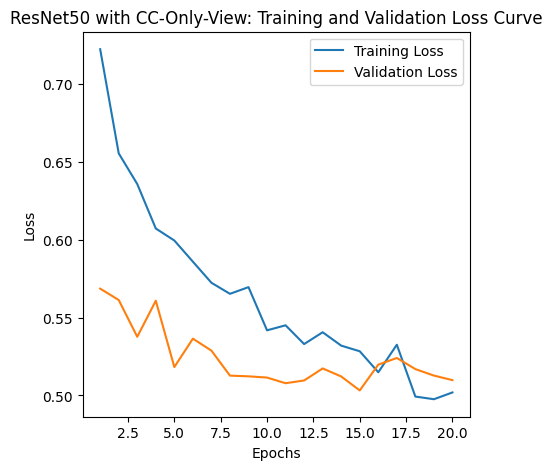

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_cc.history, 'ResNet50', 'CC-Only-View')

### DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model_cc = select_model('densenet121')
# Compile and train the DenseNet121 model with training data
densenet121_cc, _, _ = train_selected_model(densenet121_model_cc, train_dataset_cc, val_dataset_cc, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict_cc)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 36s 631ms/step - auc: 0.4181 - loss: 1.2775 - precision: 0.4403 - recall: 0.4444 - val_auc: 0.5059 - val_loss: 0.7827 - val_precision: 0.5476 - val_recall: 0.4340
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 491ms/step - auc: 0.4179 - loss: 1.3196 - precision: 0.4191 - recall: 0.4350 - val_auc: 0.4789 - val_loss: 0.8514 - val_precision: 0.4921 - val_recall: 0.5849
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 492ms/step - auc: 0.4676 - loss: 1.1521 - precision: 0.4770 - recall: 0.4657 - val_auc: 0.4840 - val_loss: 0.6908 - val_precision: 0.5556 - val_recall: 0.2830
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 20s 503ms/step - auc: 0.4689 - loss: 1.0492 - precision: 0.4871 - recall: 0.4894 - val_auc: 0.4914 - val_loss: 0.6860 - val_precision: 0.5385 - val_recall: 0.2642
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 487ms/step - auc: 0.4598 - loss: 0.9937 - precision: 0.4907 - recall: 0.4350 - val_auc: 0.4862 - val_lo

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
_, _, metrics_dict_densenet121_cc, _ = generate_predictions_and_evaluations(densenet121_cc, val_dataset_cc, val_true_labels_cc, CLASSIFICATION_THRESHOLD)

9/9 ━━━━━━━━━━━━━━━━━━━━ 8s 615ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 263ms/step - auc: 0.5059 - loss: 0.7827 - precision: 0.5476 - recall: 0.4340


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_cc_results_df = generate_results_metrics_df(
    model_name='DenseNet121',
    experimental_value='CC-Only-View',
    eval_metrics=metrics_dict_densenet121_cc,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, densenet121_cc_results_df)

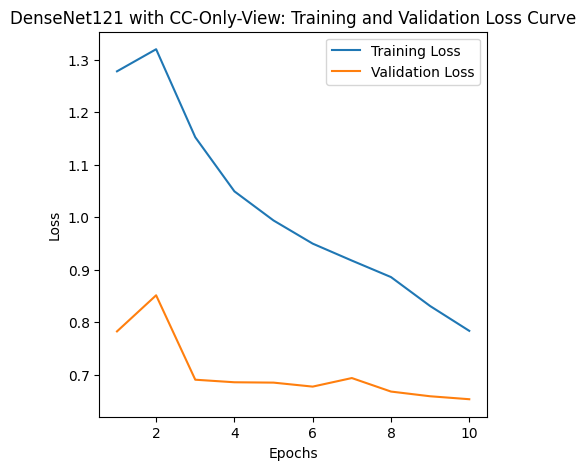

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_cc.history, 'DenseNet121', 'CC-Only-View')

### MobileNetV2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model_cc = select_model('mobilenetv2')
# Compile and train the MobileNetV2 model with training data
mobilenetv2_cc, _, _ = train_selected_model(mobilenetv2_model_cc, train_dataset_cc, val_dataset_cc, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict_cc)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 24s 467ms/step - auc: 0.4335 - loss: 0.7104 - precision: 0.4427 - recall: 0.2648 - val_auc: 0.5140 - val_loss: 0.6642 - val_precision: 0.6000 - val_recall: 0.1698
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 418ms/step - auc: 0.4918 - loss: 0.6807 - precision: 0.5341 - recall: 0.3522 - val_auc: 0.5057 - val_loss: 0.6341 - val_precision: 0.7391 - val_recall: 0.1604
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 416ms/step - auc: 0.5015 - loss: 0.6821 - precision: 0.5464 - recall: 0.3759 - val_auc: 0.5111 - val_loss: 0.6306 - val_precision: 0.8571 - val_recall: 0.0566
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 16s 406ms/step - auc: 0.5233 - loss: 0.6685 - precision: 0.5594 - recall: 0.3452 - val_auc: 0.5320 - val_loss: 0.6331 - val_precision: 0.6957 - val_recall: 0.1509
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 438ms/step - auc: 0.5076 - loss: 0.6702 - precision: 0.5171 - recall: 0.3215 - val_auc: 0.5258 - val_loss

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
_, _, metrics_dict_mobilenetv2_cc, _ = generate_predictions_and_evaluations(mobilenetv2_cc, val_dataset_cc, val_true_labels_cc, CLASSIFICATION_THRESHOLD)

9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 264ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 140ms/step - auc: 0.5140 - loss: 0.6642 - precision: 0.6000 - recall: 0.1698


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_cc_results_df = generate_results_metrics_df(
    model_name='MobileNetV2',
    experimental_value='CC-Only-View',
    eval_metrics=metrics_dict_mobilenetv2_cc,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, mobilenetv2_cc_results_df)

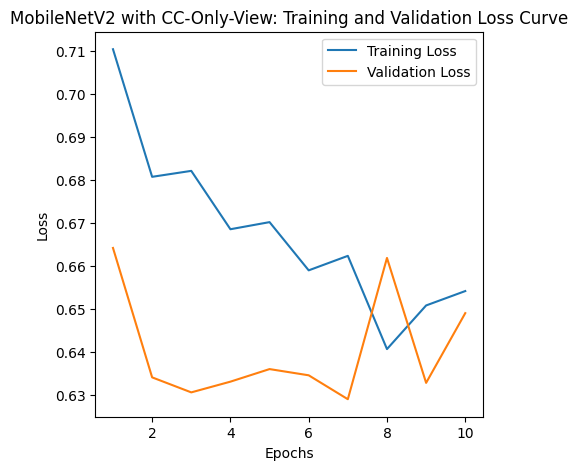

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_cc.history, 'MobileNetV2', 'CC-Only-View')

### EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model_cc = select_model('efficientnetb0')
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0_cc, _, _ = train_selected_model(efficientnetb0_model_cc, train_dataset_cc, val_dataset_cc, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict_cc)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 31s 564ms/step - auc: 0.4714 - loss: 0.6804 - precision: 0.5088 - recall: 0.1371 - val_auc: 0.6125 - val_loss: 0.6399 - val_precision: 0.6604 - val_recall: 0.3302
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 432ms/step - auc: 0.5591 - loss: 0.6337 - precision: 0.6244 - recall: 0.3026 - val_auc: 0.6266 - val_loss: 0.6060 - val_precision: 0.7000 - val_recall: 0.3962
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 431ms/step - auc: 0.5917 - loss: 0.6175 - precision: 0.6316 - recall: 0.3688 - val_auc: 0.6085 - val_loss: 0.5926 - val_precision: 0.6964 - val_recall: 0.3679
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 435ms/step - auc: 0.6113 - loss: 0.6062 - precision: 0.6604 - recall: 0.4137 - val_auc: 0.6103 - val_loss: 0.5770 - val_precision: 0.7111 - val_recall: 0.3019
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 18s 429ms/step - auc: 0.5992 - loss: 0.6049 - precision: 0.6787 - recall: 0.3995 - val_auc: 0.6381 - val_lo

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
_, _, metrics_dict_efficientnetb0_cc, _ = generate_predictions_and_evaluations(efficientnetb0_cc, val_dataset_cc, val_true_labels_cc, CLASSIFICATION_THRESHOLD)

9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 439ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 159ms/step - auc: 0.6125 - loss: 0.6399 - precision: 0.6604 - recall: 0.3302


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_cc_results_df = generate_results_metrics_df(
    model_name='EfficientNet-B0',
    experimental_value='CC-Only-View',
    eval_metrics=metrics_dict_efficientnetb0_cc,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, efficientnetb0_cc_results_df)

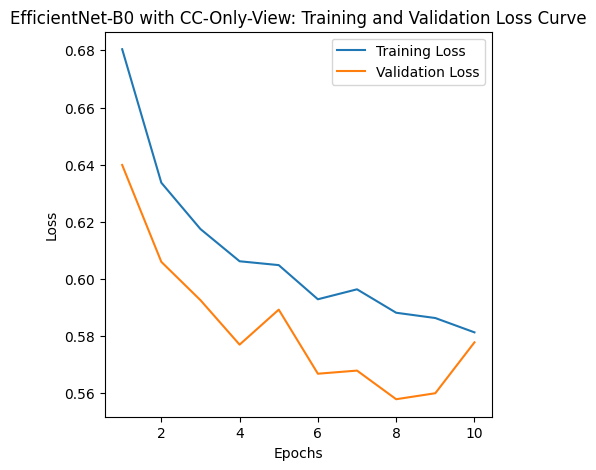

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_cc.history, 'EfficientNet-B0', 'CC-Only-View')

## MLO view only Experiment

#### tf.data Datasets for MLO-only View

In [ ]:
# Generate training and validation datasets for MLO only
train_dataset_mlo = dataset_preparation(train_df_mlo, baseline_preprocessor, BUFFER_SIZE_MLO, BATCH_SIZE, training=True)
val_dataset_mlo = dataset_preparation(val_df_mlo, baseline_preprocessor, BUFFER_SIZE_MLO, BATCH_SIZE, training=False)

### VGG16

In [ ]:
# Select the VGG16 model
vgg16_model_mlo = select_model('vgg16')
# Compile and train the VGG16 model with training data
vgg16_mlo, _, _ = train_selected_model(vgg16_model_mlo, train_dataset_mlo, val_dataset_mlo, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict_mlo)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 30s 515ms/step - auc: 0.3999 - loss: 0.9961 - precision: 0.4012 - recall: 0.4137 - val_auc: 0.4344 - val_loss: 0.7310 - val_precision: 0.4675 - val_recall: 0.2903
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 485ms/step - auc: 0.4482 - loss: 0.8442 - precision: 0.4736 - recall: 0.4657 - val_auc: 0.4987 - val_loss: 0.6891 - val_precision: 0.5256 - val_recall: 0.3306
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 501ms/step - auc: 0.4764 - loss: 0.7802 - precision: 0.4919 - recall: 0.4407 - val_auc: 0.5025 - val_loss: 0.6894 - val_precision: 0.4953 - val_recall: 0.4274
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 489ms/step - auc: 0.4655 - loss: 0.7901 - precision: 0.4855 - recall: 0.4511 - val_auc: 0.5216 - val_loss: 0.6693 - val_precision: 0.5312 - val_recall: 0.4113
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 507ms/step - auc: 0.4766 - loss: 0.7525 - precision: 0.5033 - recall: 0.4699 - val_auc: 0.5298 - val_lo

In [ ]:
# Predictions and evaluations using the trained VGG16 model
_, _, metrics_dict_vgg16_mlo, _ = generate_predictions_and_evaluations(vgg16_mlo, val_dataset_mlo, val_true_labels_mlo, CLASSIFICATION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 278ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 222ms/step - auc: 0.5511 - loss: 0.6114 - precision: 0.6333 - recall: 0.3065


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
vgg16_mlo_results_df = generate_results_metrics_df(
    model_name='VGG16',
    experimental_value='MLO-Only-View',
    eval_metrics=metrics_dict_vgg16_mlo,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, vgg16_mlo_results_df)

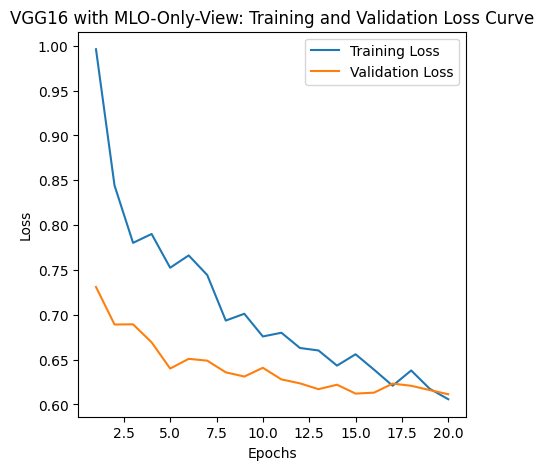

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(vgg16_mlo.history, 'VGG16', 'MLO-Only-View')

### ResNet50

In [ ]:
# Select the ResNet50 model
resnet50_model_mlo = select_model('resnet50')
# Compile and train the ResNet50 model with training data
resnet50_mlo, _, _ = train_selected_model(resnet50_model_mlo, train_dataset_mlo, val_dataset_mlo, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict_mlo)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 31s 561ms/step - auc: 0.4576 - loss: 0.7350 - precision: 0.4744 - recall: 0.3659 - val_auc: 0.5479 - val_loss: 0.6526 - val_precision: 0.5405 - val_recall: 0.4839
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 485ms/step - auc: 0.5121 - loss: 0.6672 - precision: 0.5437 - recall: 0.4657 - val_auc: 0.5718 - val_loss: 0.6151 - val_precision: 0.6415 - val_recall: 0.2742
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 512ms/step - auc: 0.5380 - loss: 0.6463 - precision: 0.5559 - recall: 0.4345 - val_auc: 0.5783 - val_loss: 0.6050 - val_precision: 0.7250 - val_recall: 0.2339
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 41s 504ms/step - auc: 0.5610 - loss: 0.6210 - precision: 0.5924 - recall: 0.4200 - val_auc: 0.5568 - val_loss: 0.6137 - val_precision: 0.6197 - val_recall: 0.3548
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 489ms/step - auc: 0.5739 - loss: 0.6049 - precision: 0.6062 - recall: 0.4449 - val_auc: 0.5706 - val_lo

In [ ]:
# Predictions and evaluations using the trained ResNet50 model
_, _, metrics_dict_resnet50_mlo, _ = generate_predictions_and_evaluations(resnet50_mlo, val_dataset_mlo, val_true_labels_mlo, CLASSIFICATION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 378ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 252ms/step - auc: 0.5505 - loss: 0.5956 - precision: 0.6346 - recall: 0.2661


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
resnet50_mlo_results_df = generate_results_metrics_df(
    model_name='ResNet50',
    experimental_value='MLO-Only-View',
    eval_metrics=metrics_dict_resnet50_mlo,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, resnet50_mlo_results_df)

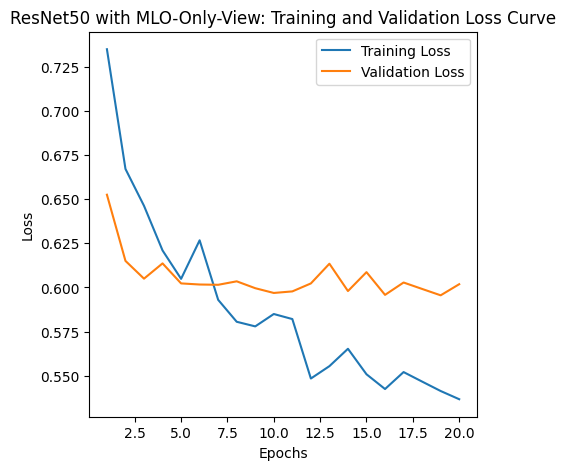

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(resnet50_mlo.history, 'ResNet50', 'MLO-Only-View')

### DenseNet121

In [ ]:
# Select the DenseNet121 model
densenet121_model_mlo = select_model('densenet121')
# Compile and train the DenseNet121 model with training data
densenet121_mlo, _, _ = train_selected_model(densenet121_model_mlo, train_dataset_mlo, val_dataset_mlo, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict_mlo)

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 40s 661ms/step - auc: 0.4228 - loss: 1.2735 - precision: 0.4246 - recall: 0.4449 - val_auc: 0.4365 - val_loss: 0.7152 - val_precision: 0.6000 - val_recall: 0.0726
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 501ms/step - auc: 0.4233 - loss: 1.1895 - precision: 0.4237 - recall: 0.4158 - val_auc: 0.4925 - val_loss: 0.7003 - val_precision: 0.5056 - val_recall: 0.3629
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 22s 499ms/step - auc: 0.4558 - loss: 1.0491 - precision: 0.4701 - recall: 0.4407 - val_auc: 0.4799 - val_loss: 0.6801 - val_precision: 0.5152 - val_recall: 0.1371
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 23s 523ms/step - auc: 0.4512 - loss: 1.0098 - precision: 0.4622 - recall: 0.4574 - val_auc: 0.4701 - val_loss: 0.7088 - val_precision: 0.6154 - val_recall: 0.0645
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 21s 497ms/step - auc: 0.4456 - loss: 0.9176 - precision: 0.4590 - recall: 0.4075 - val_auc: 0.5193 - val_lo

In [ ]:
# Predictions and evaluations using the trained DenseNet121 model
_, _, metrics_dict_densenet121_mlo, _ = generate_predictions_and_evaluations(densenet121_mlo, val_dataset_mlo, val_true_labels_mlo, CLASSIFICATION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 9s 543ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 213ms/step - auc: 0.4365 - loss: 0.7152 - precision: 0.6000 - recall: 0.0726


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
densenet121_mlo_results_df = generate_results_metrics_df(
    model_name='DenseNet121',
    experimental_value='MLO-Only-View',
    eval_metrics=metrics_dict_densenet121_mlo,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, densenet121_mlo_results_df)

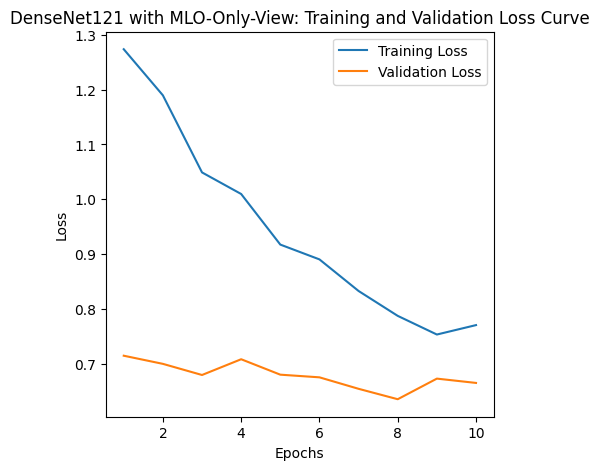

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(densenet121_mlo.history, 'DenseNet121', 'MLO-Only-View')

### MobileNetV2

In [ ]:
# Select the MobileNetV2 model
mobilenetv2_model_mlo = select_model('mobilenetv2')
# Compile and train the MobileNetV2 model with training data
mobilenetv2_mlo, _, _ = train_selected_model(mobilenetv2_model_mlo, train_dataset_mlo, val_dataset_mlo, EXPERIMENTAL_EPOCHS, early_stopping, class_weights_dict_mlo)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 26s 467ms/step - auc: 0.4470 - loss: 0.7156 - precision: 0.4706 - recall: 0.2827 - val_auc: 0.5006 - val_loss: 0.6510 - val_precision: 0.9091 - val_recall: 0.0806
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 424ms/step - auc: 0.4602 - loss: 0.6969 - precision: 0.4760 - recall: 0.2890 - val_auc: 0.5146 - val_loss: 0.6771 - val_precision: 0.5833 - val_recall: 0.2258
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 420ms/step - auc: 0.4870 - loss: 0.6834 - precision: 0.4882 - recall: 0.3430 - val_auc: 0.5323 - val_loss: 0.6723 - val_precision: 0.5800 - val_recall: 0.2339
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 419ms/step - auc: 0.5050 - loss: 0.6734 - precision: 0.5393 - recall: 0.2994 - val_auc: 0.5393 - val_loss: 0.6824 - val_precision: 0.5733 - val_recall: 0.3468
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 421ms/step - auc: 0.5146 - loss: 0.6669 - precision: 0.5887 - recall: 0.3243 - val_auc: 0.5490 - val_loss

In [ ]:
# Predictions and evaluations using the trained MobileNetV2 model
_, _, metrics_dict_mobilenetv2_mlo, _ = generate_predictions_and_evaluations(mobilenetv2_mlo, val_dataset_mlo, val_true_labels_mlo, CLASSIFICATION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 254ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 136ms/step - auc: 0.5006 - loss: 0.6510 - precision: 0.9091 - recall: 0.0806


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
mobilenetv2_mlo_results_df = generate_results_metrics_df(
    model_name='MobileNetV2',
    experimental_value='MLO-Only-View',
    eval_metrics=metrics_dict_mobilenetv2_mlo,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, mobilenetv2_mlo_results_df)

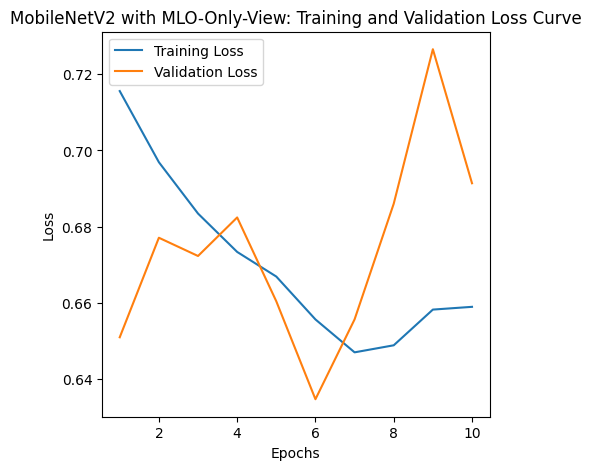

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(mobilenetv2_mlo.history, 'MobileNetV2', 'MLO-Only-View')

### EfficientNet-B0

In [ ]:
# Select the EfficientNet-B0 model
efficientnetb0_model_mlo = select_model('efficientnetb0')
# Compile and train the EfficientNet-B0 model with training data
efficientnetb0_mlo, _, _ = train_selected_model(efficientnetb0_model_mlo, train_dataset_mlo, val_dataset_mlo, EXPERIMENTAL_EPOCHS, early_stopping,
                                                class_weights_dict_mlo)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 32s 507ms/step - auc: 0.4586 - loss: 0.6869 - precision: 0.5636 - recall: 0.1289 - val_auc: 0.5591 - val_loss: 0.6568 - val_precision: 0.6552 - val_recall: 0.3065
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 444ms/step - auc: 0.5564 - loss: 0.6399 - precision: 0.5856 - recall: 0.3555 - val_auc: 0.5656 - val_loss: 0.6227 - val_precision: 0.6000 - val_recall: 0.2419
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 435ms/step - auc: 0.5762 - loss: 0.6281 - precision: 0.6041 - recall: 0.3680 - val_auc: 0.5884 - val_loss: 0.6178 - val_precision: 0.6481 - val_recall: 0.2823
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 19s 435ms/step - auc: 0.6074 - loss: 0.6129 - precision: 0.6949 - recall: 0.3410 - val_auc: 0.5811 - val_loss: 0.6350 - val_precision: 0.5743 - val_recall: 0.4677
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 20s 441ms/step - auc: 0.5846 - loss: 0.6272 - precision: 0.5897 - recall: 0.4033 - val_auc: 0.5756 - val_lo

In [ ]:
# Predictions and evaluations using the trained EfficientNet-B0 model
_, _, metrics_dict_efficientnetb0_mlo, _ = generate_predictions_and_evaluations(efficientnetb0_mlo, val_dataset_mlo, val_true_labels_mlo, CLASSIFICATION_THRESHOLD)

10/10 ━━━━━━━━━━━━━━━━━━━━ 6s 360ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 152ms/step - auc: 0.6031 - loss: 0.5681 - precision: 0.7209 - recall: 0.2500


In [ ]:
# Generate the results dataframe containing evaluation metrics computed above
efficientnetb0_mlo_results_df = generate_results_metrics_df(
    model_name='EfficientNet-B0',
    experimental_value='MLO-Only-View',
    eval_metrics=metrics_dict_efficientnetb0_mlo,
    experiment_type='views'
)
# Store the results data in results CSV file
store_experiment_results(results_file_path, efficientnetb0_mlo_results_df)

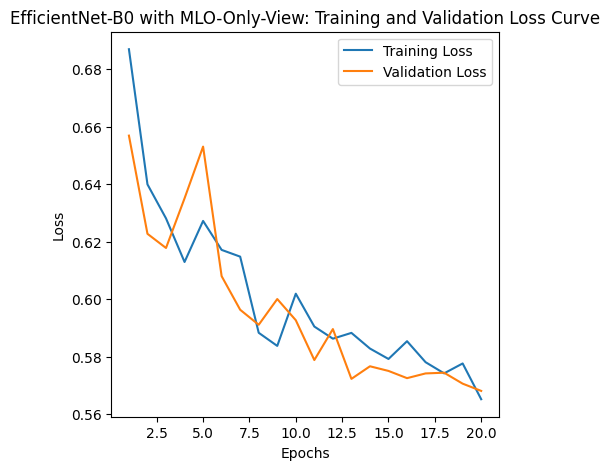

In [ ]:
# Plot training-validation loss curve
plot_training_validation_loss(efficientnetb0_mlo.history, 'EfficientNet-B0', 'MLO-Only-View')